# Market Regime Detection - EDA & Feature Engineering

**Dataset:** SPY ETF daily OHLCV data (2005–2026), ~5,326 trading days  
**Source:** Yahoo Finance via yfinance  
**Goal:** Engineer features that capture market conditions (trend, momentum, volatility) 
to serve as inputs for unsupervised regime clustering in the modeling notebook.

**Features engineered:**
- `log_return` - daily log return, captures price momentum
- `rolling_volatility` - 20-day realized volatility, captures risk regime
- `sma_ratio` - 20-day SMA / 50-day SMA, captures trend direction
- `rsi` - 14-day Relative Strength Index, captures overbought/oversold conditions

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import load_spy_data
from src.features import create_features
import config

2026-03-23 01:37:00.468 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-23 01:37:00.477 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-23 01:37:00.479 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Loading data from cache: C:\project_2\data\spy_data.csv
            Adj Close       Close        High         Low        Open  \
Date                                                                    
2005-03-15  81.497452  120.139999  121.459999  120.080002  121.419998   
2005-03-16  80.805511  119.120003  120.160004  118.900002  119.699997   
2005-03-17  80.968353  119.360001  119.739998  118.980003  119.309998   
2005-03-18  80.727913  118.540001  119.529999  118.150002  119.110001   
2005-03-21  80.428284  118.099998  118.779999  117.760002  118.709999   

              Volume  log_return  rolling_volatility  sma_ratio        rsi  
Date                                                                        
2005-03-15  62438500   -0.018065            0.007326   1.011440  44.620215  
2005-03-16  74874200   -0.015411            0.007489   1.010799  40.140175  
2005-03-17  62584200   -0.015628            0.007510   1.009935  41.625317  
2005-03-18  60232000   -0.015486            0.0

In [4]:
df = load_spy_data()
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2005-01-03,81.606003,120.300003,121.760002,119.900002,121.559998,55748000
2005-01-04,80.608780,118.830002,120.540001,118.440002,120.459999,69167600
2005-01-05,80.052574,118.010002,119.250000,118.000000,118.739998,65667300
2005-01-06,80.459572,118.610001,119.150002,118.260002,118.440002,47814700
2005-01-07,80.344215,118.440002,119.230003,118.129997,118.970001,55847700


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5326 entries, 2005-01-03 to 2026-03-05
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  5326 non-null   float64
 1   Close      5326 non-null   float64
 2   High       5326 non-null   float64
 3   Low        5326 non-null   float64
 4   Open       5326 non-null   float64
 5   Volume     5326 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 291.3 KB


In [6]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,5326.000000,5326.000000,5326.000000,5326.000000,5326.000000,5.326000e+03
mean,229.300774,256.907561,258.291607,255.318192,256.871735,1.227910e+08
std,161.490488,153.377699,154.069211,152.527605,153.341060,8.982237e+07
min,49.944580,68.110001,70.000000,67.099998,67.949997,1.527000e+07
25%,98.727646,132.692493,133.407494,131.779999,132.782505,6.522050e+07
50%,172.716621,205.709999,206.864998,204.760002,205.779999,9.208180e+07
75%,330.942261,356.042496,358.064995,353.902496,355.595001,1.501702e+08
max,695.489990,695.489990,697.840027,693.940002,697.049988,8.710263e+08


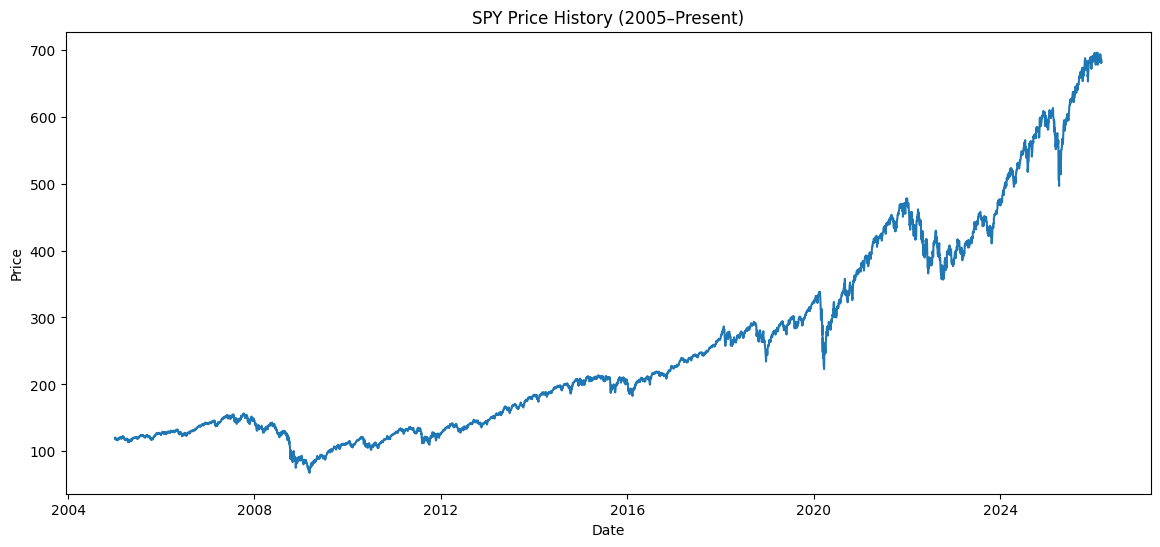

In [7]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df["Close"])
plt.title("SPY Price History (2005–Present)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [8]:
df_feat = create_features(df)
df_feat.head()

,Adj Close,Close,High,Low,Open,Volume,log_return,rolling_volatility,sma_ratio,rsi
Date,,,,,,,,,,
2005-03-15,81.497452,120.139999,121.459999,120.080002,121.419998,62438500,-0.018065,0.007326,1.011440,44.620215
2005-03-16,80.805511,119.120003,120.160004,118.900002,119.699997,74874200,-0.015411,0.007489,1.010799,40.140175
2005-03-17,80.968353,119.360001,119.739998,118.980003,119.309998,62584200,-0.015628,0.007510,1.009935,41.625317
2005-03-18,80.727913,118.540001,119.529999,118.150002,119.110001,60232000,-0.015486,0.007451,1.009139,38.143219
2005-03-21,80.428284,118.099998,118.779999,117.760002,118.709999,61244300,-0.025415,0.007464,1.008267,36.384386


## Feature Engineering

`create_features()` computes 4 technical indicators on raw OHLCV data.  
The raw dataset has 5,326 rows, after computing rolling features with a 
50-day window, **49 initial rows are dropped** due to insufficient history.  
Final dataset: **5,277 trading days**.

In [9]:
df_feat.shape

(5277, 10)

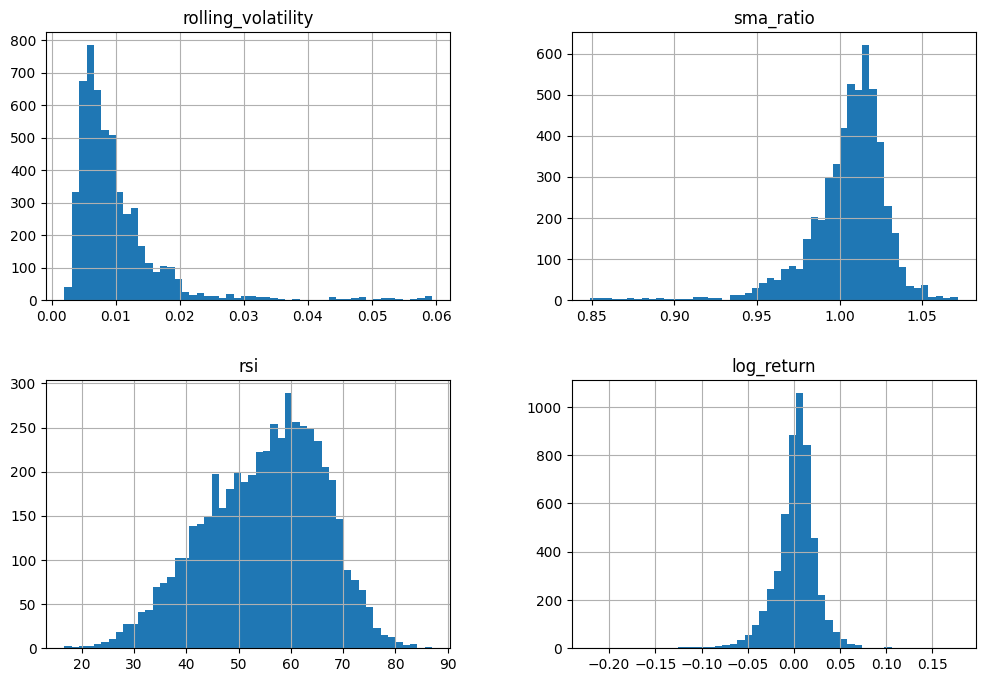

In [10]:
df_feat[[
    "rolling_volatility",
    "sma_ratio",
    "rsi",
    "log_return"
]].hist(bins=50, figsize=(12,8))

plt.show()

## Distribution Analysis

- `log_return` shows fat tails - extreme moves are more frequent than a normal 
  distribution would predict. This is why regime detection matters: a single 
  model assuming constant volatility would misprice risk during crisis periods.
- `rolling_volatility` is right-skewed - most days are calm, but a few 
  crisis periods (2008, 2020) dominate the tail.
- `rsi` is roughly uniform between 30–70, with few extreme readings.

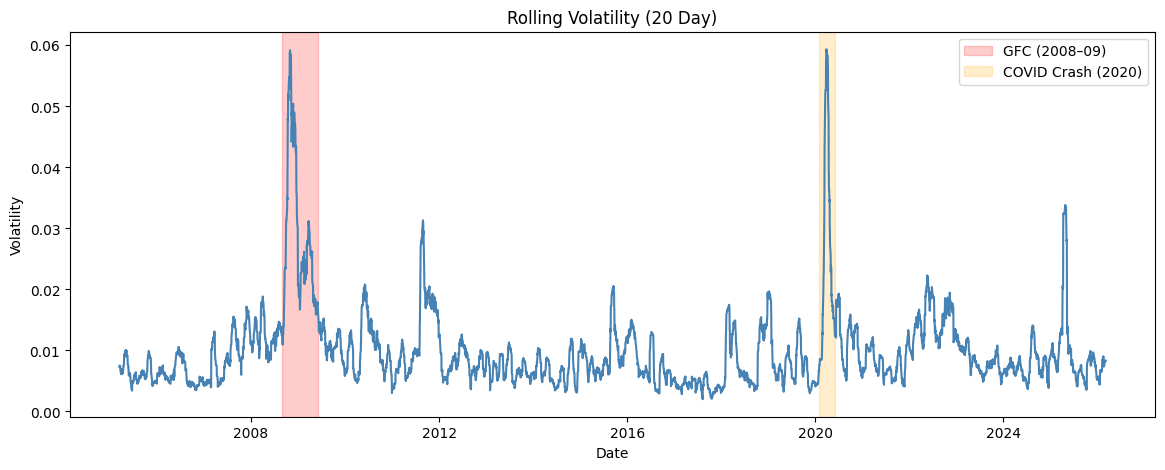

In [11]:
plt.figure(figsize=(14,5))
plt.plot(df_feat.index, df_feat["rolling_volatility"], color="steelblue")

plt.axvspan("2008-09-01", "2009-06-01", alpha=0.2, color="red", label="GFC (2008–09)")
plt.axvspan("2020-02-01", "2020-06-01", alpha=0.2, color="orange", label="COVID Crash (2020)")

plt.title("Rolling Volatility (20 Day)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

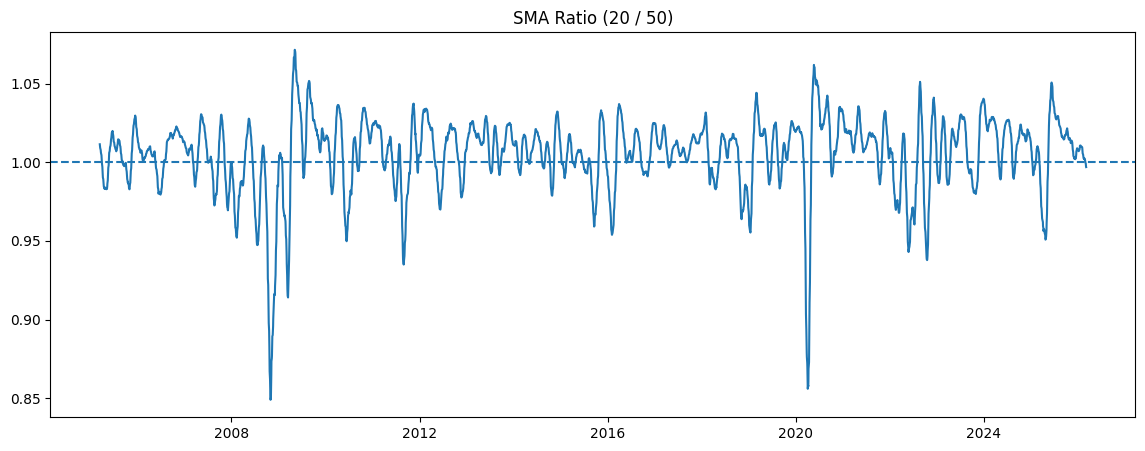

In [12]:
plt.figure(figsize=(14,5))
plt.plot(df_feat.index, df_feat["sma_ratio"])
plt.axhline(1, linestyle="--")
plt.title("SMA Ratio (20 / 50)")
plt.show()

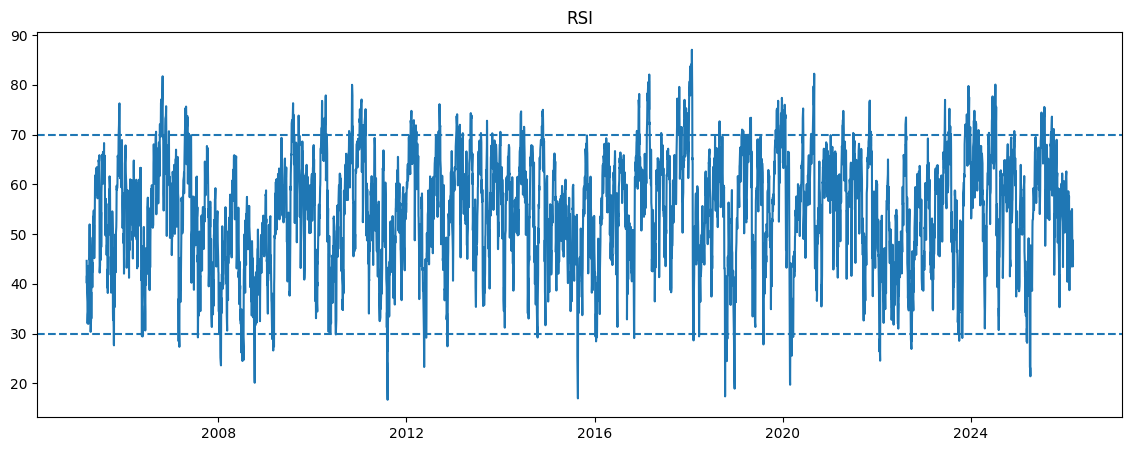

In [13]:
plt.figure(figsize=(14,5))
plt.plot(df_feat.index, df_feat["rsi"])
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.title("RSI")
plt.show()

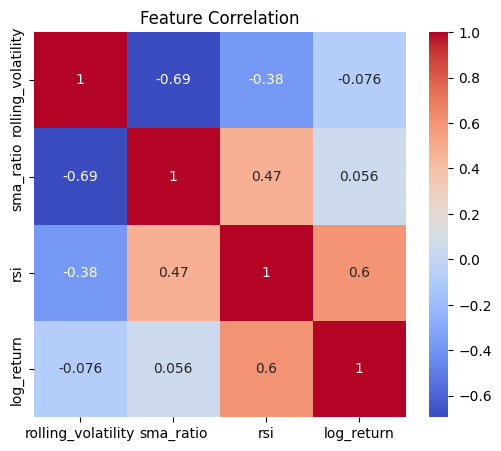

In [14]:
corr = df_feat[[
    "rolling_volatility",
    "sma_ratio",
    "rsi",
    "log_return"
]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [15]:
df_feat.to_csv(config.OUTPUT_DIR / "feature_dataset.csv")

## Summary — Key Findings

1. **Volatility is regime-dependent** - two distinct spikes (GFC 2008, COVID 2020) 
   confirm that market conditions are not stationary. A single model cannot 
   capture both calm and crisis periods.
2. **SMA ratio crosses 1.0 repeatedly** - each crossing marks a trend regime change 
   (bull → bear or bear → bull).
3. **RSI extremes are rare** - fewer than 5% of days hit overbought (>70) or 
   oversold (<30) territory, suggesting momentum signals are high-value when they fire.
4. **Features are weakly correlated** - the heatmap shows no multicollinearity issues, 
   making all 4 features useful inputs for clustering.

These findings motivate the KMeans clustering approach in `02_model_training.ipynb`.